In [ ]:
# WORKSHOP 4 - DEVNAGARI DIGIT CLASSIFICATION
#2408658

In [ ]:
# 1. IMPORT LIBRARIES
import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import load_model

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


2. UPLOAD AND EXTRACT DATASET

In [ ]:
zip_file_name = "DevanagariHandwrittenDigitDataset.zip"
extract_path = "/content/"

# Extract zip
with zipfile.ZipFile(zip_file_name, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")


Dataset extracted successfully!


3. DEFINE DATASET PATHS

In [ ]:
base_dir = "/content/DevanagariHandwrittenDigitDataset"
train_dir = os.path.join(base_dir, "Train")
test_dir = os.path.join(base_dir, "Test")

print("Train path exists:", os.path.exists(train_dir))
print("Test path exists:", os.path.exists(test_dir))

print("Train folders:", os.listdir(train_dir))
print("Test folders:", os.listdir(test_dir))

Train path exists: True
Test path exists: True
Train folders: ['digit_6', 'digit_8', 'digit_0', 'digit_2', 'digit_5', 'digit_4', 'digit_7', 'digit_3', 'digit_9', 'digit_1']
Test folders: ['digit_6', 'digit_8', 'digit_0', 'digit_2', 'digit_5', 'digit_4', 'digit_7', 'digit_3', 'digit_9', 'digit_1']


4. IMAGE PARAMETERS

In [ ]:
img_height = 28
img_width = 28
num_classes = 10

5. LOAD IMAGES USING PIL

In [ ]:
def load_images_from_folder(folder):
    images = []
    labels = []

    # Sort folder names to keep digit_0, digit_1, ..., digit_9 in proper order
    class_names = sorted(os.listdir(folder))
    class_names = [name for name in class_names if os.path.isdir(os.path.join(folder, name))]

    # Map folder names to numeric labels
    class_map = {name: i for i, name in enumerate(class_names)}
    print(f"\nClass mapping for {folder}:")
    print(class_map)

    for class_name in class_names:
        class_path = os.path.join(folder, class_name)
        label = class_map[class_name]

        for filename in os.listdir(class_path):
            file_path = os.path.join(class_path, filename)

            try:
                # Open image
                img = Image.open(file_path).convert("L")      # Convert to grayscale
                img = img.resize((img_width, img_height))     # Resize to 28x28
                img = np.array(img, dtype=np.float32) / 255.0 # Normalize to [0,1]

                images.append(img)
                labels.append(label)

            except Exception as e:
                print(f"Skipping file {file_path} because of error: {e}")

    images = np.array(images)
    labels = np.array(labels)

    return images, labels

# Load train and test data
x_train, y_train = load_images_from_folder(train_dir)
x_test, y_test = load_images_from_folder(test_dir)

print("\nOriginal shapes:")
print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("x_test shape:", x_test.shape)
print("y_test shape:", y_test.shape)


Class mapping for /content/DevanagariHandwrittenDigitDataset/Train:
{'digit_0': 0, 'digit_1': 1, 'digit_2': 2, 'digit_3': 3, 'digit_4': 4, 'digit_5': 5, 'digit_6': 6, 'digit_7': 7, 'digit_8': 8, 'digit_9': 9}

Class mapping for /content/DevanagariHandwrittenDigitDataset/Test:
{'digit_0': 0, 'digit_1': 1, 'digit_2': 2, 'digit_3': 3, 'digit_4': 4, 'digit_5': 5, 'digit_6': 6, 'digit_7': 7, 'digit_8': 8, 'digit_9': 9}

Original shapes:
x_train shape: (17000, 28, 28)
y_train shape: (17000,)
x_test shape: (3000, 28, 28)
y_test shape: (3000,)


6. RESHAPE FOR KERAS

In [ ]:
# Keras expects grayscale images as (num_samples, height, width, 1)
x_train = x_train.reshape(-1, img_height, img_width, 1)
x_test = x_test.reshape(-1, img_height, img_width, 1)

# One-hot encode labels
y_train_cat = to_categorical(y_train, num_classes=num_classes)
y_test_cat = to_categorical(y_test, num_classes=num_classes)

print("\nAfter reshaping and encoding:")
print("x_train shape:", x_train.shape)
print("y_train_cat shape:", y_train_cat.shape)
print("x_test shape:", x_test.shape)
print("y_test_cat shape:", y_test_cat.shape)


After reshaping and encoding:
x_train shape: (17000, 28, 28, 1)
y_train_cat shape: (17000, 10)
x_test shape: (3000, 28, 28, 1)
y_test_cat shape: (3000, 10)


7. VISUALIZE SAMPLE IMAGES

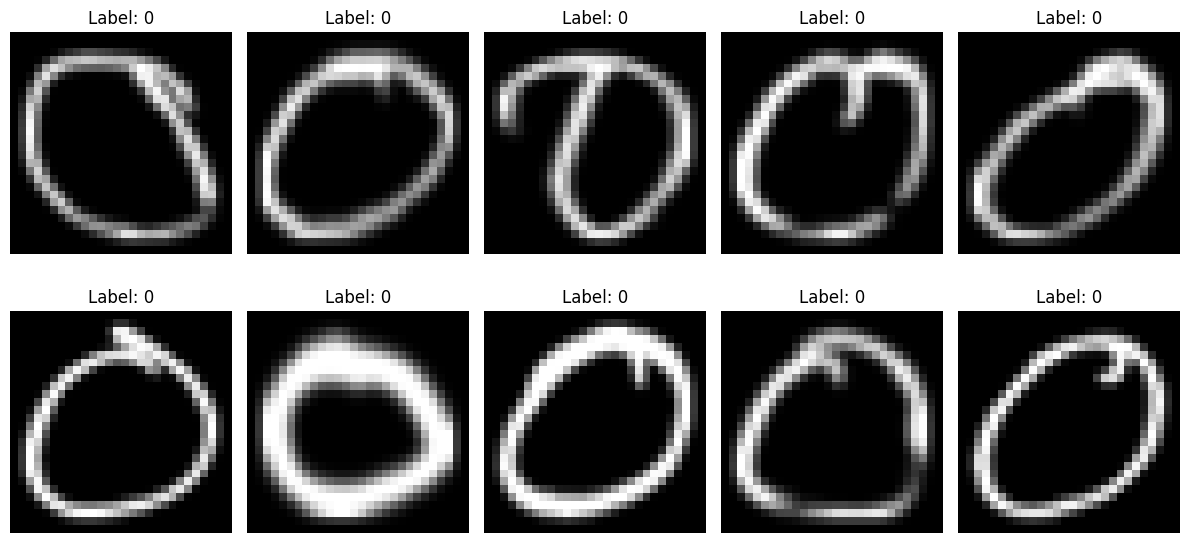

In [ ]:
plt.figure(figsize=(12, 6))
for i in range(min(10, len(x_train))):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i].reshape(28, 28), cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")
plt.tight_layout()
plt.show()

8. BUILD THE FCN MODEL

In [ ]:
model = keras.Sequential([
    keras.layers.Input(shape=(28, 28, 1)),
    keras.layers.Flatten(),
    keras.layers.Dense(64, activation="sigmoid"),
    keras.layers.Dense(128, activation="sigmoid"),
    keras.layers.Dense(256, activation="sigmoid"),
    keras.layers.Dense(10, activation="softmax")
])

print("\nModel Summary:")
model.summary()


Model Summary:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

9. COMPILE THE MODEL

In [ ]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

10. DEFINE CALLBACKS

In [ ]:
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="best_devnagari_model.keras",
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True,
        verbose=1
    )
]

11. TRAIN THE MODEL

In [ ]:
history = model.fit(
    x_train,
    y_train_cat,
    batch_size=128,
    epochs=20,
    validation_split=0.2,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3227 - loss: 1.9428
Epoch 1: val_accuracy improved from None to 0.00000, saving model to best_devnagari_model.keras

Epoch 1: finished saving model to best_devnagari_model.keras
107/107 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.4953 - loss: 1.5883 - val_accuracy: 0.0000e+00 - val_loss: 7.6572
Epoch 2/20
 98/107 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8159 - loss: 0.6544
Epoch 2: val_accuracy did not improve from 0.00000
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8389 - loss: 0.5240 - val_accuracy: 0.0000e+00 - val_loss: 9.0785
Epoch 3/20
100/107 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9052 - loss: 0.3083
Epoch 3: val_accuracy did not improve from 0.00000
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9165 - loss: 0.2800 - val_accuracy: 0.0000e+00 - val_loss: 9.7320
Epoch 4/20
105/107 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9365 - loss: 0.2125
Epoch 4: val_accuracy did not im

12. PLOT TRAINING HISTORY

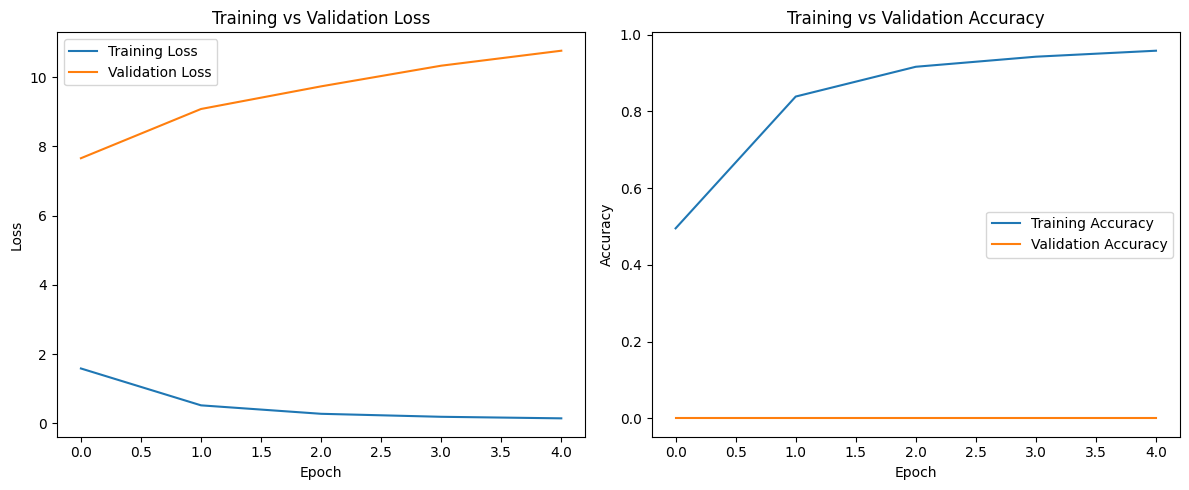

In [ ]:
train_loss = history.history['loss']
val_loss = history.history['val_loss']
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

plt.figure(figsize=(12, 5))

# Loss graph
plt.subplot(1, 2, 1)
plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

# Accuracy graph
plt.subplot(1, 2, 2)
plt.plot(train_acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

plt.tight_layout()
plt.show()


 13. EVALUATE THE MODEL

In [ ]:
test_loss, test_acc = model.evaluate(x_test, y_test_cat, verbose=2)
print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

94/94 - 0s - 3ms/step - accuracy: 0.6167 - loss: 2.1813

Test Loss: 2.1813
Test Accuracy: 0.6167


14. SAVE THE MODEL

In [ ]:
model.save("devnagari_fcn_model.h5")
print("\nModel saved as devnagari_fcn_model.h5")


Model saved as devnagari_fcn_model.h5


15. LOAD THE SAVED MODEL

In [ ]:
loaded_model = load_model("devnagari_fcn_model.h5")
print("Saved model loaded successfully!")

# Re-evaluate loaded model
loaded_loss, loaded_acc = loaded_model.evaluate(x_test, y_test_cat, verbose=2)
print(f"\nLoaded Model Test Loss: {loaded_loss:.4f}")
print(f"Loaded Model Test Accuracy: {loaded_acc:.4f}")


Saved model loaded successfully!
94/94 - 1s - 6ms/step - accuracy: 0.6167 - loss: 2.1813

Loaded Model Test Loss: 2.1813
Loaded Model Test Accuracy: 0.6167


16. MAKE PREDICTIONS

In [ ]:
predictions = loaded_model.predict(x_test)
predicted_labels = np.argmax(predictions, axis=1)

print("\nFirst 10 predicted labels:", predicted_labels[:10])
print("First 10 true labels:     ", y_test[:10])

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

First 10 predicted labels: [0 0 0 0 0 0 0 0 0 0]
First 10 true labels:      [0 0 0 0 0 0 0 0 0 0]


17. DISPLAY SOME PREDICTIONS

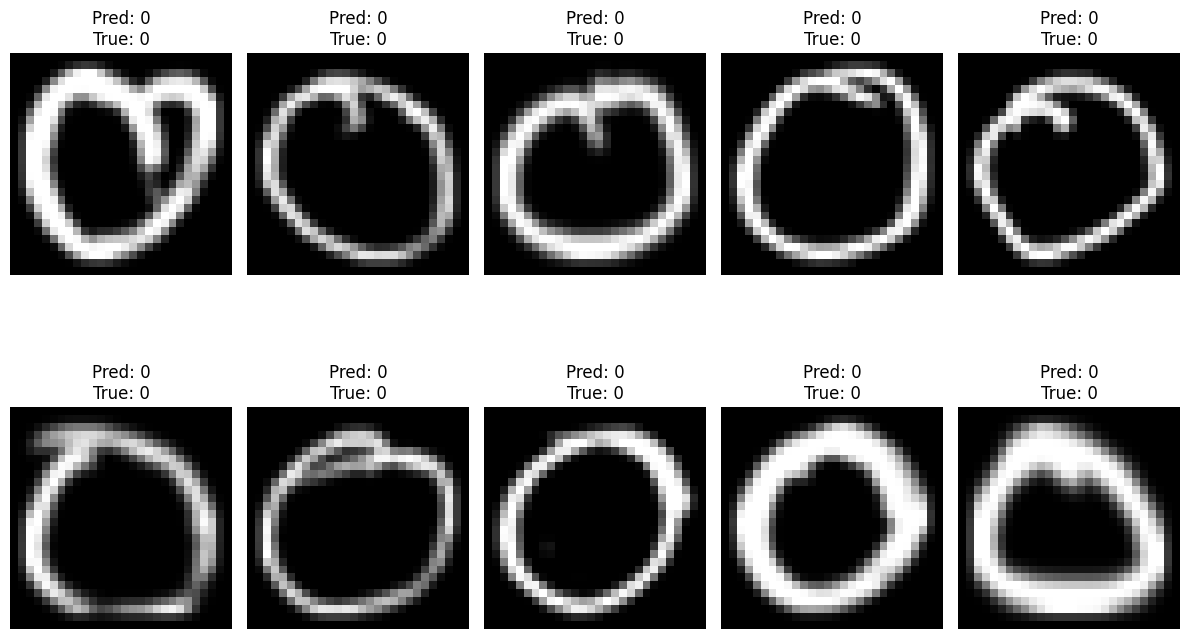

In [ ]:
plt.figure(figsize=(12, 8))
for i in range(min(10, len(x_test))):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.title(f"Pred: {predicted_labels[i]}\nTrue: {y_test[i]}")
    plt.axis("off")
plt.tight_layout()
plt.show()

18. OPTIONAL: SHOW MISCLASSIFIED IMAGES


Number of misclassified images: 1150


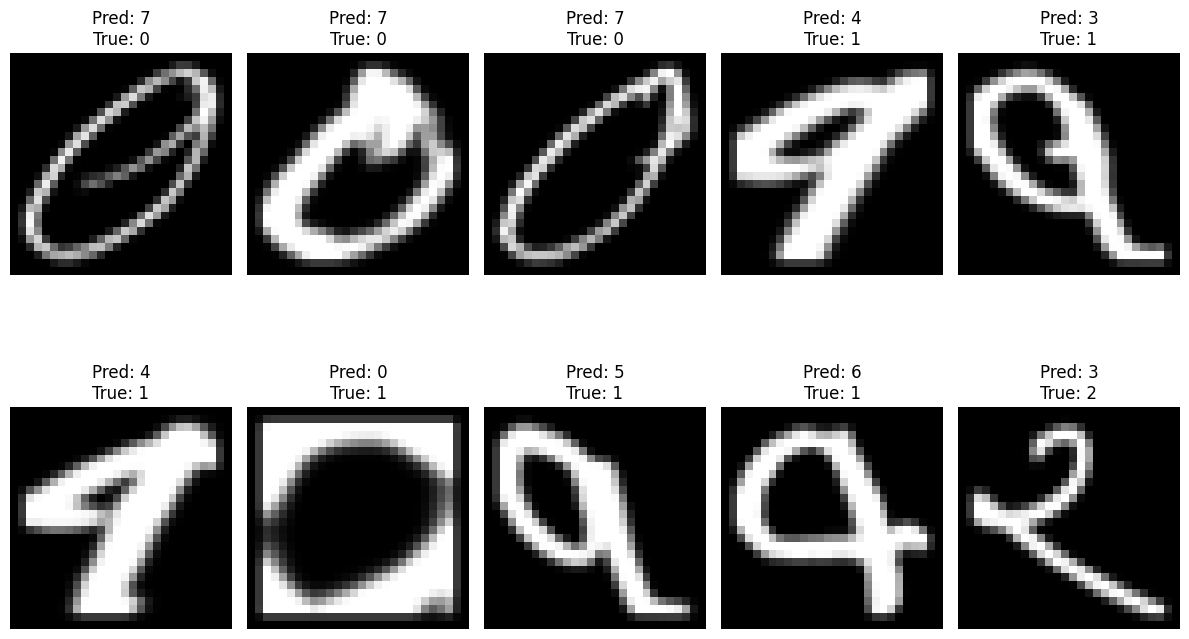

In [ ]:
misclassified_idx = np.where(predicted_labels != y_test)[0]
print("\nNumber of misclassified images:", len(misclassified_idx))

if len(misclassified_idx) > 0:
    plt.figure(figsize=(12, 8))
    for i, idx in enumerate(misclassified_idx[:10]):
        plt.subplot(2, 5, i + 1)
        plt.imshow(x_test[idx].reshape(28, 28), cmap='gray')
        plt.title(f"Pred: {predicted_labels[idx]}\nTrue: {y_test[idx]}")
        plt.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("No misclassified images found.")